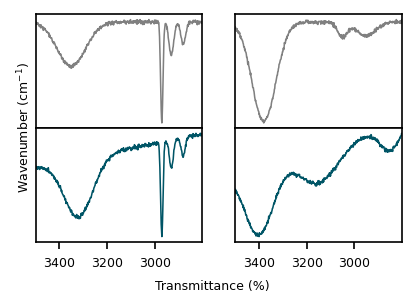

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import numpy as np
from data_sets import CharacterizationMethod, data_sets, cm2inch
from enum import Enum

class PlotType(Enum):
    Line2D = "Line2D"


# --- Data Params ---

data_sets_ir = data_sets[CharacterizationMethod.IR]

# --- Matplotlibrc Params ---

##     - LINES
##     - PATCHES
##     - HATCHES
##     - BOXPLOT
##     - FONT
##     - TEXT
##     - LaTeX
##     - AXES
##     - DATES
##     - TICKS
##     - GRIDS
##     - LEGEND
## --- Figure Params ---
##     - IMAGES
##     - CONTOUR PLOTS
##     - ERRORBAR PLOTS
##     - HISTOGRAM PLOTS
##     - SCATTER PLOTS
##     - AGG RENDERING
##     - PATHS
##     - SAVING FIGURES


## --- Figure Params ---

fig_size = cm2inch(8, 5)
dpi = 150

## --- Text Params ---

font_size = 6
plt.rc('font', size=font_size)
plt.rc('axes', titlesize=font_size)
plt.rc('axes', labelsize=font_size)
plt.rc('xtick', labelsize=font_size)
plt.rc('ytick', labelsize=font_size)
plt.rc('legend', fontsize=font_size)
plt.rc('figure', titlesize=font_size + 3)

## --- Grid Params 1 ---

wspace = 0.2
hspace = 0

## --- Axis Params 1 ---

x_axis_n_min_loc = 2
x_is_visible = True
y_axis_n_min_loc = 2
y_is_visible = True

# --- Non-Matplotlibrc Params ---

## --- Grid Params ---

n_rows = 2
n_cols = 2
width_ratios = [1, 1]
height_ratios = [1, 1]
n_plots = 4

## --- Axis Params ---

xlim = (3500, 2800)
xlabel = r"Wavenumber (cm$^{-1}$)"
ylim = None
ylabel = r"Transmittance (%)"

## --- Plot Params ---

plot_type = PlotType.Line2D
lw = 0.75


# --- Plotting ---

fig = plt.figure(figsize=fig_size, dpi=dpi)
gs = GridSpec(1, 1)
gs1 = GridSpecFromSubplotSpec(
    nrows=n_rows, 
    ncols=n_cols, 
    subplot_spec=gs[0], 
    width_ratios=width_ratios, 
    height_ratios=height_ratios, 
    wspace=wspace, 
    hspace=hspace
)

axes = np.empty((n_rows, n_cols), dtype=object)
for i in range(n_plots):
    row = i // n_cols
    col = i % n_cols
    axes[row, col] = fig.add_subplot(gs1[row, col])


# Dataset mapping
plots = [
    (axes[0, 0], data_sets_ir[0].x, data_sets_ir[0].y, 'gray', 'IPA'),
    (axes[1, 0], data_sets_ir[1].x, data_sets_ir[1].y, '#005566', 'IPA + PbI$_2$'),
    (axes[0, 1], data_sets_ir[2].x, data_sets_ir[2].y, 'gray', 'FIPA'),
    (axes[1, 1], data_sets_ir[3].x, data_sets_ir[3].y, '#005566', 'FIPA + PbI$_2$')
]

for ax, x, y, col, lbl in plots:
    ax.plot(x, y, color=col, linewidth=lw)
    
    # Ticks
    ax.set_xlim(xlim[0], xlim[1]+1)
    ax.set_ylim(ylim)
    ax.set_yticks([])


fig.text(0.1, 0.5, ylabel, ha='center', va='center', rotation="vertical")
fig.text(0.5, -0.05, xlabel, ha='center')

axes[0, 0].set_xticks([])
axes[0, 1].set_xticks([])

plt.show()
